# Data Pre-Processing

Dataset: 

## Imports and data loading:

In [24]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew
from dython.nominal import cramers_v, correlation_ratio

# Load the dataset

filename = "compas-scores-two-years.csv"
path = os.path.join(os.getcwd(), '..', 'data', filename)
df = pd.read_csv(path)

## Dataset Overview:

In [25]:
print(f"Dataset Shape: {df.shape}")
print(f"Count of Unique Individuals: {df['id'].nunique()}")

Dataset Shape: (7214, 53)
Count of Unique Individuals: 7214


## Variable Types

In [26]:
print("\nData types:")
print(df.dtypes)


Data types:
id                           int64
name                           str
first                          str
last                           str
compas_screening_date          str
sex                            str
dob                            str
age                          int64
age_cat                        str
race                           str
juv_fel_count                int64
decile_score                 int64
juv_misd_count               int64
juv_other_count              int64
priors_count                 int64
days_b_screening_arrest    float64
c_jail_in                      str
c_jail_out                     str
c_case_number                  str
c_offense_date                 str
c_arrest_date                  str
c_days_from_compas         float64
c_charge_degree                str
c_charge_desc                  str
is_recid                     int64
r_case_number                  str
r_charge_degree                str
r_days_from_arrest         float64
r_offen

## Null Values

In [27]:
print("\nNull or NAN counts:")
print(df.isnull().sum())


Null or NAN counts:
id                            0
name                          0
first                         0
last                          0
compas_screening_date         0
sex                           0
dob                           0
age                           0
age_cat                       0
race                          0
juv_fel_count                 0
decile_score                  0
juv_misd_count                0
juv_other_count               0
priors_count                  0
days_b_screening_arrest     307
c_jail_in                   307
c_jail_out                  307
c_case_number                22
c_offense_date             1159
c_arrest_date              6077
c_days_from_compas           22
c_charge_degree               0
c_charge_desc                29
is_recid                      0
r_case_number              3743
r_charge_degree            3743
r_days_from_arrest         4898
r_offense_date             3743
r_charge_desc              3801
r_jail_in          

## Numerical Variable Analysis

In [28]:
df.describe()

,id,age,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_days_from_compas,is_recid,r_days_from_arrest,violent_recid,is_violent_recid,decile_score.1,v_decile_score,priors_count.1,start,end,event,two_year_recid
count,7214.000000,7214.000000,7214.000000,7214.000000,7214.000000,7214.000000,7214.000000,6907.000000,7192.000000,7214.000000,2316.000000,0.0,7214.000000,7214.000000,7214.000000,7214.000000,7214.000000,7214.000000,7214.000000,7214.000000
mean,5501.255753,34.817993,0.067230,4.509565,0.090934,0.109371,3.472415,3.304763,57.731368,0.481148,20.269430,NaN,0.113529,4.509565,3.691849,3.472415,11.465068,553.436651,0.382867,0.450652
std,3175.706870,11.888922,0.473972,2.856396,0.485239,0.501586,4.882538,75.809505,329.740215,0.499679,74.871668,NaN,0.317261,2.856396,2.510148,4.882538,46.954563,399.020583,0.486120,0.497593
min,1.000000,18.000000,0.000000,1.000000,0.000000,0.000000,0.000000,-414.000000,0.000000,0.000000,-1.000000,NaN,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2735.250000,25.000000,0.000000,2.000000,0.000000,0.000000,0.000000,-1.000000,1.000000,0.000000,0.000000,NaN,0.000000,2.000000,1.000000,0.000000,0.000000,148.250000,0.000000,0.000000
50%,5509.500000,31.000000,0.000000,4.000000,0.000000,0.000000,2.000000,-1.000000,1.000000,0.000000,0.000000,NaN,0.000000,4.000000,3.000000,2.000000,0.000000,530.500000,0.000000,0.000000
75%,8246.500000,42.000000,0.000000,7.000000,0.000000,0.000000,5.000000,0.000000,2.000000,1.000000,1.000000,NaN,0.000000,7.000000,5.000000,5.000000,1.000000,914.000000,1.000000,1.000000
max,11001.000000,96.000000,20.000000,10.000000,13.000000,17.000000,38.000000,1057.000000,9485.000000,1.000000,993.000000,NaN,1.000000,10.000000,10.000000,38.000000,937.000000,1186.000000,1.000000,1.000000


## Categorical Variable Analysis

In [29]:
exclude_vars = [
    # Identifiers & High-Cardinality Text
    'name', 'first', 'last', 'c_case_number', 'r_case_number', 'vr_case_number',
    # 'c_charge_desc', 'r_charge_desc', 'vr_charge_desc',
    
    # Timestamps & Dates
    'compas_screening_date', 'screening_date', 'v_screening_date', 'dob',
    'c_jail_in', 'c_jail_out', 'c_offense_date', 'c_arrest_date',
    'r_offense_date', 'r_jail_in', 'r_jail_out', 'vr_offense_date',
    'in_custody', 'out_custody',
    
    # Redundant Columns
    # 'age_cat', 'score_text', 'v_score_text'
]
categorical_vars = [col for col in df.select_dtypes(include=['object', 'category', 'string']).columns if col not in exclude_vars]

categorical_vars = [col for col in df.select_dtypes(include=['object', 'category', 'string']).columns if col not in exclude_vars]
for col in categorical_vars:
    print(f"Col: {col}")
    print(f"Number of categories: {df[col].nunique()}")
    print("Percentage:")
    print(df[col].value_counts(normalize=True).mul(100).round(2))
    print()

Col: sex
Number of categories: 2
Percentage:
sex
Male      80.66
Female    19.34
Name: proportion, dtype: float64

Col: age_cat
Number of categories: 3
Percentage:
age_cat
25 - 45            56.96
Greater than 45    21.85
Less than 25       21.19
Name: proportion, dtype: float64

Col: race
Number of categories: 6
Percentage:
race
African-American    51.23
Caucasian           34.02
Hispanic             8.83
Other                5.23
Asian                0.44
Native American      0.25
Name: proportion, dtype: float64

Col: c_charge_degree
Number of categories: 2
Percentage:
c_charge_degree
F    64.68
M    35.32
Name: proportion, dtype: float64

Col: c_charge_desc
Number of categories: 437
Percentage:
c_charge_desc
Battery                          16.09
arrest case no charge            15.82
Possession of Cocaine             6.60
Grand Theft in the 3rd Degree     5.92
Driving While License Revoked     2.78
                                 ...  
Purchase Of Cocaine               0.01
Deliv

### COMPAS score distribution by race

/tmp/ipykernel_377390/237699438.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


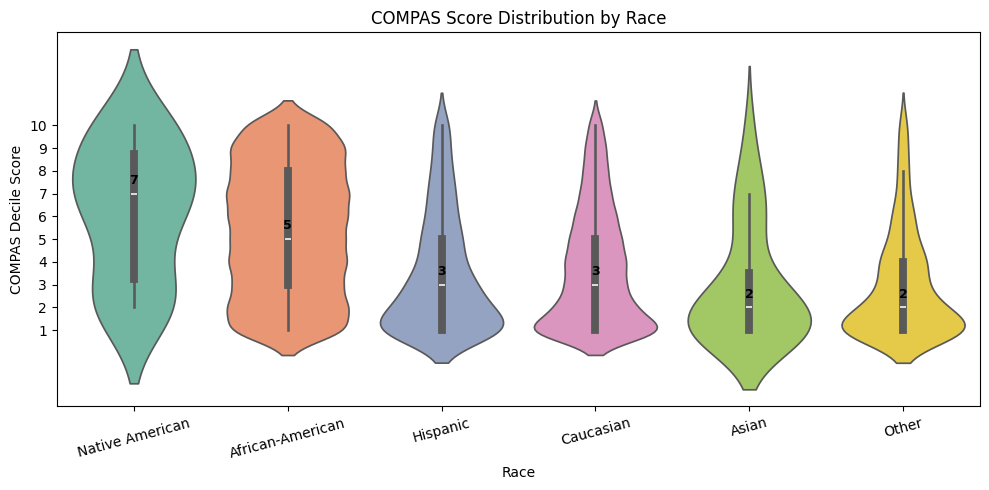

In [30]:
race_order = (
    df.groupby('race')['decile_score']
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

fig, ax = plt.subplots(figsize=(10, 5))

sns.violinplot(
    data=df, x='race', y='decile_score',
    order=race_order, inner='box',
    palette='Set2', ax=ax, legend=False
)

ax.set_xlabel('Race')
ax.set_ylabel('COMPAS Decile Score')
ax.set_title('COMPAS Score Distribution by Race')
ax.set_yticks(range(1, 11))
ax.tick_params(axis='x', rotation=15)

for i, race in enumerate(race_order):
    median = df[df['race'] == race]['decile_score'].median()
    ax.text(i, median + 0.3, f'{median:.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## Data Cleaning

### Duplicate Columns

There are 2 columns with duplicates in the dataset: `decile_score` and `priors_count`.
The `screening_date` seems to also be a duplicate of the `compas_screening_date`.

We'll confirm that all are truly duplicate before taking any decisions.

In [31]:
print(f"decile_score and decile_score.1 are identical: {df['decile_score'].equals(df['decile_score.1'])}")
print(f"priors_count and priors_count.1 are identical: {df['priors_count'].equals(df['priors_count.1'])}")
print(f"screening_date and compas_screening_date are identical: {df['screening_date'].equals(df['compas_screening_date'])}")

decile_score and decile_score.1 are identical: True
priors_count and priors_count.1 are identical: True
screening_date and compas_screening_date are identical: True


Since all are truly duplicates, we'll remove `decile_score.1` and `priors_count.1` and `compas_screening_date`.

In [32]:
df = df.drop(columns=['decile_score.1', 'priors_count.1', 'compas_screening_date'])

### 0 Variance Columns

There are 2 columns with 0 variance in the dataset: `type_of_assessment` and `v_type_of_assessment`.

We'll remove both of them, since they are not providing any information for the model.

In [33]:
print(df["type_of_assessment"].value_counts(normalize=True).mul(100).round(2), end="\n\n")
print(df["v_type_of_assessment"].value_counts(normalize=True).mul(100).round(2))

df = df.drop(columns=['type_of_assessment', 'v_type_of_assessment'])

type_of_assessment
Risk of Recidivism    100.0
Name: proportion, dtype: float64

v_type_of_assessment
Risk of Violence    100.0
Name: proportion, dtype: float64


### Irrelevant Columns

There are a couple of columns that don't provide any relevant information for the models and just act as noise.

These are mostly text columns that are not necesserily categorical:
- `id`
- `name`, `first`, `last`
- `c_case_number`, `r_case_number`, `vr_case_number`

In [34]:
columns_to_drop = [
    'id', 'name', 'first', 'last', 
    'c_case_number', 'r_case_number', 'vr_case_number'
]

df = df.drop(columns=columns_to_drop)

### Redundant Columns

These are columns that are redundant, because there are already other columns with equivalent information more fit for more model training:
(the columns after the arrow are the ones that best represent the information)
- `age_cat` -> `age`
- `score_text`, `v_score_text` -> `decile_score`, `v_decile_score` 
- `c_charge_desc`, `r_charge_desc`, `vr_charge_desc` -> `c_charge_degree`, `r_charge_degree`, `vr_charge_degree`

Just to be sure, we calculated the correlations between these fields.

In [35]:
results = []

# Define your pairs explicitly: (Column to potentially drop, Column to test against, Method)
study_configs = [
    ("age_cat", "age", "eta"),
    ("score_text", "decile_score", "eta"),
    ("v_score_text", "v_decile_score", "eta"),
    # ("c_charge_desc", "c_charge_degree", "cramers_v"),
    ("r_charge_desc", "r_charge_degree", "cramers_v"),
    ("vr_charge_desc", "vr_charge_degree", "cramers_v")
]

for target_col, reference_col, method in study_configs:
    # Ensure columns exist in df before testing
    if target_col in df.columns and reference_col in df.columns:
        if method == "eta":
            val = correlation_ratio(df[target_col], df[reference_col])
        else:
            val = cramers_v(df[target_col], df[reference_col])
            
        results.append({
            "target_col": target_col,
            "reference_col": reference_col,
            "metric": method,
            "value": val
        })

# Create study DataFrame
corr_study = pd.DataFrame(results)
display(corr_study)

# 1. Start with your base identification columns

# 2. Add columns from study where correlation is >= 0.85 (rounded)
# We round to 2 decimal places to catch 0.846+
redundant_cols = corr_study[corr_study['value'].round(2) >= 0.85]['target_col'].tolist()

print(f"Final columns identified for removal: {redundant_cols}")

# 3. Perform the drop
df = df.drop(columns=[c for c in redundant_cols if c in df.columns])

# DISCLAIMER: This code was generated using AI

,target_col,reference_col,metric,value
0,age_cat,age,eta,0.898127
1,score_text,decile_score,eta,0.936545
2,v_score_text,v_decile_score,eta,0.914027
3,r_charge_desc,r_charge_degree,cramers_v,0.951749
4,vr_charge_desc,vr_charge_degree,cramers_v,0.964059


Final columns identified for removal: ['age_cat', 'score_text', 'v_score_text', 'r_charge_desc', 'vr_charge_desc']


### Future variables

There's a bunch of variables in the dataset that the model should not have access to.

This is because these features were obtained after the COMPAS score was calculated.

For that reason, I'm going to remove all those features, to avoid data leakage.

In [36]:
columns_to_drop = [
    'c_jail_in',
    'c_jail_out',
    # 'is_recid',
    'r_charge_degree',
    'r_days_from_arrest',
    'r_offense_date',
    'r_jail_in',
    'r_jail_out',
    'violent_recid',
    'is_violent_recid',
    'vr_charge_degree',
    'vr_offense_date',
    'v_decile_score',
    'v_screening_date',
    'in_custody',
    'out_custody',
    'start',
    'end',
    'event',
    'two_year_recid',
    'in_custody',
    'out_custody'
]

df = df.drop(columns=columns_to_drop)

df.columns.tolist()

['sex',
 'dob',
 'age',
 'race',
 'juv_fel_count',
 'decile_score',
 'juv_misd_count',
 'juv_other_count',
 'priors_count',
 'days_b_screening_arrest',
 'c_offense_date',
 'c_arrest_date',
 'c_days_from_compas',
 'c_charge_degree',
 'c_charge_desc',
 'is_recid',
 'screening_date']

### Date Validations

There's not a single row where c_offense_date and c_arrest_date are both not null.
I'll take both the columns and merge them into one.

In [37]:
df['dob'] = pd.to_datetime(df['dob'], errors='coerce')


both_not_null = df[df['c_offense_date'].notna() & df['c_arrest_date'].notna()]
print(f"Total rows with both dates: {len(both_not_null)}")

df['event_date'] = df['c_offense_date'].combine_first(df['c_arrest_date'])
print(f"Total rows with null event_date: {df['event_date'].isna().sum() / len(df) :.2%}")

df= df.dropna(subset=['event_date'])
df['event_date'] = pd.to_datetime(df['event_date'], errors='coerce')

df['event_year'] = df['event_date'].dt.year

print(f"Total rows with null event_date: {df['event_date'].isna().sum() / len(df) :.2%}")

df = df.drop(columns=['c_offense_date', 'c_arrest_date'])

Total rows with both dates: 0
Total rows with null event_date: 0.30%
Total rows with null event_date: 0.00%


We must now filter the rows where the offense or arrest took effect too far in the timeline from the compas screening.

In [38]:
valid_timeline = (df['days_b_screening_arrest'] <= 30) & (df['days_b_screening_arrest'] >= -30)
df = df[valid_timeline]

columns_to_drop = [
    'days_b_screening_arrest',
    'c_days_from_compas',
    'screening_date',
]

df = df.drop(columns=columns_to_drop)

### Race Misrepresentation

There are some races that severly under-represented in this dataset.

For that reason, we will group every race under 1% of representation into the 'other' race category.

In [39]:
# 1. Set your threshold (1% = 0.01)
threshold = 0.01

# 2. Calculate the percentage of each race in the dataset
race_percentages = df['race'].value_counts(normalize=True)

# 3. Create a list of the races that fall strictly below the threshold
races_to_group = race_percentages[race_percentages < threshold].index
print(f"Races being grouped into 'Other': {list(races_to_group)}")

# 4. Replace those specific values with 'Other'
df['race'] = df['race'].replace(races_to_group, 'Other')

df['race'] = df['race'].str.lower().str.strip()

# Verify the new distribution
print("\nNew Race Distribution (%):")
print(df['race'].value_counts(normalize=True).mul(100).round(2))

Races being grouped into 'Other': ['Asian', 'Native American']

New Race Distribution (%):
race
african-american    51.44
caucasian           34.07
hispanic             8.25
other                6.24
Name: proportion, dtype: float64


## Feature Engineering

Im going to try and extract some features from the current dataset, because it was reduced by quite a bit.

In [40]:
df['age_at_event'] = (df['event_date'] - pd.to_datetime(df['dob'], errors='coerce')).dt.days // 365.25

df['adult_years'] = df['age_at_event'] - 18
df['adult_years'] = df['adult_years'].clip(lower=1)

df['priors_per_adult_year'] = df['priors_count'] / df['adult_years']

# Magnitude: Total Juvenile Offenses
df['total_juv_count'] = df['juv_fel_count'] + df['juv_misd_count'] + df['juv_other_count']

# Binary: Does a juvenile record exist? (1 = Yes, 0 = No)
df['has_juv_record'] = (df['total_juv_count'] > 0).astype(int)

df['first_offense'] = (df['priors_count'] == 0 & ~df['has_juv_record']).astype(int)

def categorize_charge(description):
    desc = str(description).lower()
    if any(word in desc for word in ['assault', 'battery', 'murder', 'manslaughter', 'robbery']):
        return 'violent'
    elif any(word in desc for word in ['drug', 'cocaine', 'marijuana', 'possession']):
        return 'drug'
    elif any(word in desc for word in ['theft', 'burglary', 'fraud', 'trespass']):
        return 'property'
    elif any(word in desc for word in ['driving', 'license', 'traffic', 'dui']):
        return 'driving'
    else:
        return 'other'

df['charge_category'] = df['c_charge_desc'].apply(categorize_charge)

df['young_man'] = ((df['age_at_event'] < 25) & (df['sex'] == 'Male')).astype(int)

df['velocity_repeat_offender'] = ((df['priors_per_adult_year'] > 1.0) & (df['charge_category'] == 'violent') & (df['c_charge_degree'] == 'F')).astype(int)

df = df.drop(['c_charge_desc', 'adult_years', 'event_date', 'dob', 'age'], axis=1)
# This code was generated mostly using AI

- `age_at_event`: Age at which the subject commited the offense / was arrested.
- `priors_per_adult_year`: Ratio of adult crimes comitted by the amount of adult years of the subject.
- `total_juv_count`: Total amount of juvenile charges.
- `has_juv_record`: Boolean for if a subject has a juvenile record.
- `first_offense`: Boolean for if a subject has any criminal record.
- `charge_category`: Normalized value for `c_charge_desc`.
- `young_man`: Flag for when a subject is a man less than 25 years old.
- `velocity_repeat_offender`: Flag for when a subject has one or more offenses per year and the charge is a felony associated with violence. Essentially a flag for dangerous repeat offenders.

Also created boolean flags for categorical values.

> **_NOTE:_** Dropped the race_other instead of race_african-american, for better visualization later.

In [41]:
categorical_cols = ['sex', 'c_charge_degree', 'charge_category']
for col in [*categorical_cols, 'race']:
    df[col] = df[col].str.lower().str.strip()

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df = pd.get_dummies(df, columns=['race'])
df = df.drop(columns=['race_other'])
# Convert all boolean columns to 1s and 0s
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)


## Final Dataset

In [42]:
df.shape

(6172, 23)

In [43]:
df.dtypes

juv_fel_count                 int64
decile_score                  int64
juv_misd_count                int64
juv_other_count               int64
priors_count                  int64
is_recid                      int64
event_year                    int32
age_at_event                float64
priors_per_adult_year       float64
total_juv_count               int64
has_juv_record                int64
first_offense                 int64
young_man                     int64
velocity_repeat_offender      int64
sex_male                      int64
c_charge_degree_m             int64
charge_category_drug          int64
charge_category_other         int64
charge_category_property      int64
charge_category_violent       int64
race_african-american         int64
race_caucasian                int64
race_hispanic                 int64
dtype: object

In [44]:
df.isna().sum()

juv_fel_count               0
decile_score                0
juv_misd_count              0
juv_other_count             0
priors_count                0
is_recid                    0
event_year                  0
age_at_event                0
priors_per_adult_year       0
total_juv_count             0
has_juv_record              0
first_offense               0
young_man                   0
velocity_repeat_offender    0
sex_male                    0
c_charge_degree_m           0
charge_category_drug        0
charge_category_other       0
charge_category_property    0
charge_category_violent     0
race_african-american       0
race_caucasian              0
race_hispanic               0
dtype: int64

### Variable Correlations to Target

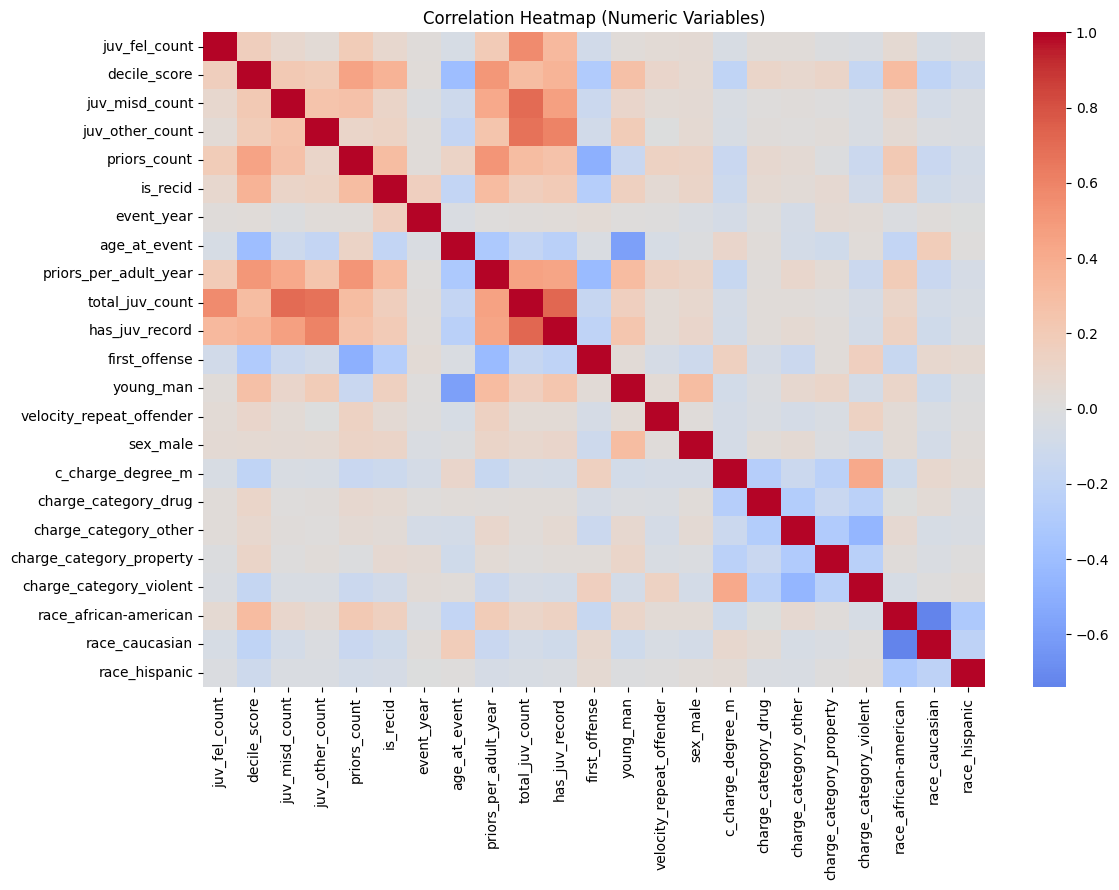


Numeric relevance to 'decile_score' (Pearson correlation):


,pearson_corr
priors_per_adult_year,0.515766
priors_count,0.447830
age_at_event,-0.403355
is_recid,0.367186
has_juv_record,0.354127
race_african-american,0.311165
total_juv_count,0.298629
first_offense,-0.293019
young_man,0.273206
juv_misd_count,0.217722



Numeric relevance to 'race_african-american' (Pearson correlation):


,pearson_corr
race_caucasian,-0.739953
decile_score,0.311165
race_hispanic,-0.308577
priors_count,0.215184
priors_per_adult_year,0.196389
age_at_event,-0.186496
first_offense,-0.155292
is_recid,0.152363
has_juv_record,0.138094
young_man,0.109324


In [45]:
from scipy.stats import chi2_contingency

targets = ["decile_score", "race_african-american"]

# ---------- Numeric correlation ----------
numeric_cols = df.select_dtypes(include="number").columns.tolist()
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, square=False)
plt.title("Correlation Heatmap (Numeric Variables)")
plt.tight_layout()
plt.show()

for target in targets:
    if target in corr_matrix.columns:
        corr_with_target = (
            corr_matrix[target]
            .drop(labels=[target], errors="ignore")
            .sort_values(key=lambda s: s.abs(), ascending=False)
        )
    print(f"\nNumeric relevance to '{target}' (Pearson correlation):")
    display(corr_with_target.to_frame(name="pearson_corr"))



# DISCLAIMER: This code was generated using AI

In [46]:
df.to_csv(os.path.join(os.getcwd(), '..', 'data', 'compas_preprocessed.csv'), index=False)